# Exploring single-cell TCR data with Dandelion
## Goals
- Understand single-cell TCR sequencing (V(D)J data)
- Get familiar with the AIRR format
- Use Dandelion to load, QC and call clonotypes
- Integrate TCR information back into a Scanpy AnnData
- Visualize clonal expansion as a clonotype network and on UMAP

> In Tutorial 1 we built a UMAP from gene expression (GEX) alone.
> Here we add a second view of the same cells, their TCR sequences, and see how clonality maps onto the GEX landscape.

## A quick primer on TCR sequencing

T cells recognise antigens through their T cell receptor (TCR), a heterodimer of two chains, typically `α (alpha)` and `β (beta)` in conventional T cells.
Each chain is built by recombining one `V`, one `J`, and (for β chain only) one `D` gene segment, with random nucleotides added at the junctions. This process generates a highly diverse repertoire of `CDR3` sequences that underpins antigen recognition.

Key terms we'll use throughout:

- `Contig` - one assembled TCR transcript (one chain) detected in one cell
- `AIRR format` - the community-standard tabular format for V(D)J data
- `Productive` - a contig with an in-frame, intact CDR3 (a working chain)
- `Clonotype` - a group of cells sharing the same TCR (clonal progeny of one ancestor T cell)

### How does V(D)J data actually reach us?

A single-cell 5′ experiment (10x Genomics, SeekGene, etc.) produces two libraries from the same cells: a gene-expression library and an enriched V(D)J library. After sequencing, an assembly pipeline (e.g. Cell Ranger) takes the raw reads and produces, per sample:

- `filtered_contig.fasta` - the assembled contig sequences (nucleotides)
- `filtered_contig_annotations.csv` - a table with one row per contig: cell barcode, V/D/J gene calls, CDR3 sequence, productive flag, UMI count, …
- `airr_rearrangement.tsv` - the same information but in the standardised AIRR format (community standard, the preferred input for downstream tools)

These raw outputs share `cell barcodes` with the matched gene-expression data, which is how we link TCR clonality back onto the GEX UMAP later.

<img src="https://media.springernature.com/full/springer-static/image/art%3A10.1038%2Fs41592-024-02243-4/MediaObjects/41592_2024_2243_Fig1_HTML.png">

## Dandelion: a package for analyzing single cell BCR/TCR data

[Dandelion](https://sc-dandelion.readthedocs.io) is a Python package for analysing single-cell BCR/TCR V(D)J-seq data. It can:

- read the raw outputs above (`.fasta` and `.csv`, or AIRR `.tsv`) into a structured `Dandelion` object
- (re)annotate contigs with IgBLAST for more accurate V/D/J gene calls
- QC contigs and flag problematic cells (doublets, orphan chains, …)
- define clonotypes based on V/J gene + CDR3 identity
- build a clonotype network showing which cells share TCRs
- integrate seamlessly with Scanpy, as TCR info is pushed into `adata.obs` so it can be plotted on the GEX UMAP

A `Dandelion` object holds two linked tables:
- `.data` - one row per contig (the AIRR table)
- `.metadata` - one row per cell, summarising its chain composition

In this tutorial we skip the assembly and IgBLAST steps: the `.zipddl` files (Dandelion's compressed native format) we'll load have already been built from the CSV/FASTA outputs upstream, so we can jump straight into analysis. The matched gene-expression data has likewise been saved as `AnnData` (`.h5ad`).

### Install Dandelion and dependencies

In [1]:
!pip install -qqq scanpy[leiden] numpy==2.0.2 pandas==2.2.2
!pip install -qqq "sc-dandelion[polars] @ git+https://github.com/tuonglab/dandelion.git"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.1/176.1 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.0/40.0 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 96.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 104.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 49.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 138.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.8/116.8 kB 5.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.3/160.3 kB 17.1 MB/s eta 0:00:00
  Installing build dependencies ...

In [2]:
import scanpy as sc
import pandas as pd
import polars as pl
import numpy as np
import anndata as ad
import dandelion as ddl
import matplotlib.pyplot as plt

## Download the data

In [3]:
import gdown

datasets = {
    "vdj_PICA0209.zipddl":"https://drive.google.com/uc?id=1NCSYmJsLACt8__Dn2THRtOwPNNHV-oDN",
    "vdj_PICA0208.zipddl":"https://drive.google.com/uc?id=1eZDmOjJeakyrVD-qgrQaOUC0fimlTVST",
    "adata_PICA0209.h5ad":"https://drive.google.com/uc?id=1Kwf5jZSR6niFL-DHY47qXTh4IvwHNEiD",
    "adata_PICA0208.h5ad":"https://drive.google.com/uc?id=1FavDStS1pdzpF8BPAyCL2ujQHB5XwAPh",
}

for filename, url in datasets.items():
    print(f"Downloading {filename}")
    gdown.download(url, str(filename), quiet=True)

## Load the data and meet the AIRR format

We'll work with only PICA0208 for now and bring in the second sample only at the end of the tutorial for comparison.

In [4]:
adata = sc.read_h5ad("adata_PICA0208.h5ad")
vdj = ddl.read_zipddl("vdj_PICA0208.zipddl")

<img src="https://sc-dandelion.readthedocs.io/en/latest/_images/dandelion_class2.png">

### The AIRR table `vdj.data`

The actual TCR information lives in `vdj.data` -- a long-format table where each row is one contig (one chain in one cell).

A cell with a complete αβ TCR shows up as two rows: one for the β (VDJ) chain and one for the α (VJ) chain. Cells with extra chains have more rows.

> Note: in recent versions of Dandelion, `vdj.data` is a polars LazyFrame. This update allows Dandelion to run way much faster than the old pandas version.
> Just remember, to actually see the data of a polars LazyFrame, we need to call `.collect()`.

In [5]:
print(type(vdj.data.collect()))
print(vdj.data.collect())
print("columns:", vdj.data.collect().columns)

<class 'polars.dataframe.frame.DataFrame'>
shape: (19_286, 109)
┌───────────┬───────────┬──────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ sequence_ ┆ sequence  ┆ rev_comp ┆ productiv ┆ … ┆ j_call_se ┆ j_call_se ┆ j_call_su ┆ rearrange │
│ id        ┆ ---       ┆ ---      ┆ e         ┆   ┆ quence_st ┆ quence_en ┆ pport_mul ┆ ment_stat │
│ ---       ┆ str       ┆ str      ┆ ---       ┆   ┆ art_multi ┆ d_multima ┆ timappers ┆ us        │
│ str       ┆           ┆          ┆ str       ┆   ┆ map…      ┆ ppe…      ┆ ---       ┆ ---       │
│           ┆           ┆          ┆           ┆   ┆ ---       ┆ ---       ┆ str       ┆ str       │
│           ┆           ┆          ┆           ┆   ┆ str       ┆ str       ┆           ┆           │
╞═══════════╪═══════════╪══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ PICA0175- ┆ AGATGCCTG ┆ F        ┆ T         ┆ … ┆ 399       ┆ 442       ┆ 3.31e-19  ┆ Standard  │
│ 0213_pool ┆ AGCTAGGAA ┆  

The columns we'll actually use most:

| column | meaning |
|---|---|
| `cell_id` | which cell this contig came from |
| `locus` | `TRA` (α chain) or `TRB` (β chain) |
| `productive` | does this contig encode a functional chain? |
| `v_call`, `d_call`, `j_call` | the V / D / J gene segments used |
| `junction_aa` | the CDR3 amino-acid sequence |
| `umi_count` | how many UMIs (unique RNA molecules) support this contig |

In [6]:
# Preview a few rows
key_cols = [
    "cell_id",
    "locus",
    "productive",
    "v_call",
    "j_call",
    "junction_aa",
    "umi_count",
]
print(vdj.data.collect().select(key_cols).head(5))

shape: (5, 7)
┌───────────────────┬───────┬────────────┬─────────────┬────────────┬──────────────────┬───────────┐
│ cell_id           ┆ locus ┆ productive ┆ v_call      ┆ j_call     ┆ junction_aa      ┆ umi_count │
│ ---               ┆ ---   ┆ ---        ┆ ---         ┆ ---        ┆ ---              ┆ ---       │
│ str               ┆ str   ┆ str        ┆ str         ┆ str        ┆ str              ┆ i64       │
╞═══════════════════╪═══════╪════════════╪═════════════╪════════════╪══════════════════╪═══════════╡
│ PICA0175-0213_Poo ┆ TRB   ┆ T          ┆ TRBV2*01    ┆ TRBJ2-7*01 ┆ CASSGQGNYEQYF    ┆ 15        │
│ l_6_AAACCAAAG…    ┆       ┆            ┆             ┆            ┆                  ┆           │
│ PICA0175-0213_Poo ┆ TRA   ┆ T          ┆ TRAV12-1*01 ┆ TRAJ4*01   ┆ CVVSQGGYNKLIF    ┆ 7         │
│ l_6_AAACCAAAG…    ┆       ┆            ┆             ┆            ┆                  ┆           │
│ PICA0175-0213_Poo ┆ TRB   ┆ F          ┆ TRBV7-2*01  ┆ TRBJ2-4*01 ┆ CASSTSG

---
### 🏋️ Exercise 1 — Explore the AIRR table

`vdj.data` is a polars LazyFrame with one row per contig. Let's get familiar with it.

1. How many contigs are in `vdj.data` in total? (remember `.collect()`)
2. Filter to only **productive** contigs (`productive == "T"`). How many are there?
3. How many unique cells are represented?

**Hint:** Polars syntax is similar to pandas but slightly different. Try:
- `.collect().shape` for dimensions
- `.collect().filter(pl.col("productive") == "T")` to filter
- `.collect()["cell_id"].n_unique()` for unique counts

In [7]:
# 1. Total number of contigs
print("Total contigs:", )

# 2. Productive contigs only
productive = vdj.data.collect().filter()
print("Productive contigs:", productive.shape[0])

# 3. Unique cells
print("Unique cells:", )

Total contigs:
Productive contigs: 19286
Unique cells:


### The per-cell summary `vdj.metadata`

There's also a second table, `vdj.metadata`, where each row is one cell. Dandelion summarises the chain composition per cell here, which is the table that gets transferred into `adata.obs` later. Like `.data`, this is also a polars LazyFrame.

In [8]:
vdj.metadata.collect().select(
    ["locus_VDJ", "locus_VJ", "productive_VDJ", "productive_VJ", "chain_status"]
).head()

locus_VDJ,locus_VJ,productive_VDJ,productive_VJ,chain_status
str,str,str,str,str
"""TRB""","""TRA""","""T""","""T""","""Single pair"""
"""TRB""","""TRA""","""T""","""T""","""Single pair"""
"""TRB""","""TRA|TRA""","""T""","""T|T""","""Ambiguous"""
"""TRB""","""TRA""","""T""","""T""","""Single pair"""
"""TRB""","""TRA|TRA""","""T""","""T|T""","""Ambiguous"""


## Converting to `pandas`

You can also inspect the object with pandas dataframes:

In [9]:
vdj.to_pandas()

In [10]:
vdj.data

,sequence_id,sequence,rev_comp,productive,v_call,d_call,j_call,sequence_alignment,germline_alignment,junction,...,sequence_alignment_aa,v_sequence_alignment_aa,d_sequence_alignment_aa,j_sequence_alignment_aa,j_call_multimappers,j_call_multiplicity,j_call_sequence_start_multimappers,j_call_sequence_end_multimappers,j_call_support_multimappers,rearrangement_status
sequence_id,,,,,,,,,,,,,,,,,,,,,
PICA0175-0213_pool6_AAACCAAAGAAAGTGC_contig_1,PICA0175-0213_pool6_AAACCAAAGAAAGTGC_contig_1,AGATGCCTGAGCTAGGAAAGGCCTCATTCCTGCTGTGATCCTGCCA...,F,T,TRBV2*01,None,TRBJ2-7*01,GAACCTGAAGTCACCCAGACTCCCAGCCATCAGGTCACACAGATGG...,GAACCTGAAGTCACCCAGACTCCCAGCCATCAGGTCACACAGATGG...,TGTGCCAGCAGTGGACAGGGAAACTACGAGCAGTACTTC,...,EPEVTQTPSHQVTQMGQEVILRCVPISNHLYFYWYRQILGQKVEFL...,EPEVTQTPSHQVTQMGQEVILRCVPISNHLYFYWYRQILGQKVEFL...,None,YEQYFGPGTRLTVT,TRBJ2-7*01,1.0,399,442,3.31e-19,Standard
PICA0175-0213_pool6_AAACCAAAGAAAGTGC_contig_2,PICA0175-0213_pool6_AAACCAAAGAAAGTGC_contig_2,GGGGCTTTTTTCTAATTGGTAGGACAGATTCTTTTTATGATTCCTA...,F,T,TRAV12-1*01,None,TRAJ4*01,CGGAAGGAGGTGGAGCAGGATCCTGGACCCTTCAATGTTCCAGAGG...,CGGAAGGAGGTGGAGCAGGATCCTGGACCCTTCAATGTTCCAGAGG...,TGTGTGGTGTCCCAAGGCGGCTACAATAAGCTGATTTTT,...,RKEVEQDPGPFNVPEGATVAFNCTYSNSASQSFFWYRQDCRKEPKL...,RKEVEQDPGPFNVPEGATVAFNCTYSNSASQSFFWYRQDCRKEPKL...,None,GYNKLIFGAGTRLAVHP,TRAJ4*01,1.0,474,528,1.37e-23,Standard
PICA0175-0213_pool6_AAACCAAAGAAAGTGC_contig_3,PICA0175-0213_pool6_AAACCAAAGAAAGTGC_contig_3,ACAGTGATCCTGATCTGGTAAAGCTCCCATCCTGCCCTGACCCTGC...,F,F,TRBV7-2*01,TRBD2*01,TRBJ2-4*01,GGAGCTGGAGTCTCCCAGTCCCCCAGTAACAAGGTCACAGAGAAGG...,GGAGCTGGAGTCTCCCAGTCCCCCAGTAACAAGGTCACAGAGAAGG...,TGTGCCAGCAGCACTAGCGGGGGGGCCTAGCCAAAAACATTCAGTA...,...,GAGVSQSPSNKVTEKGKDVELRCDPISGHTALYWYRQSLGQGLEFL...,GAGVSQSPSNKVTEKGKDVELRCDPISGHTALYWYRQSLGQGLEFL...,TSGG,PKTFSTSAPGPGSQCW,TRBJ2-4*01,1.0,406,455,1.57e-22,Standard
PICA0175-0213_pool6_AAACCAAAGGTCACGT_contig_1,PICA0175-0213_pool6_AAACCAAAGGTCACGT_contig_1,ACAGTGATCCTGATCTGGTAAAGCTCCCATCCTGCCCTGACCCTGC...,F,T,TRBV7-2*02,None,TRBJ2-3*01,GGAGCTGGAGTCTCCCAGTCCCCCAGTAACAAGGTCACAGAGAAGG...,GGAGCTGGAGTCTCCCAGTCCCCCAGTAACAAGGTCACAGAGAAGG...,TGTGCCAGCAGCTTATTTCCAGAAGCTTTCACAGATACGCAGTATTTT,...,GAGVSQSPSNKVTEKGKDVELRCDPISGHTALYWYRQRLGQGLEFL...,GAGVSQSPSNKVTEKGKDVELRCDPISGHTALYWYRQRLGQGLEFL...,None,TDTQYFGPGTRLTVL,TRBJ2-3*01,1.0,407,453,7.28e-21,Standard
PICA0175-0213_pool6_AAACCAAAGGTCACGT_contig_2,PICA0175-0213_pool6_AAACCAAAGGTCACGT_contig_2,AGAACACATCCAGGCTCCTTAAGGGAAAGCCTCTTTCTGTTTCTGA...,F,T,TRAV8-6*02,None,TRAJ18*01,GCCCAGTCTGTGACCCAGCTTGACAGCCAAGTCCCTGTCTTTGAAG...,GCCCAGTCTGTGACCCAGCTTGACAGCCAAGTCCCTGTCTTTGAAG...,TGTGCTGTGAATGGTAGAGGCTCAACCCTGGGGAGGCTATACTTT,...,AQSVTQLDSQVPVFEEAPVELRCNYSSSVSVYLFWYVQYPNQGLQL...,AQSVTQLDSQVPVFEEAPVELRCNYSSSVSVYLFWYVQYPNQGLQL...,None,RGSTLGRLYFGRGTQLTVWP,TRAJ18*01,1.0,511,571,1.46e-28,Standard
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
PICA0175-0213_pool6_GTTGTGGGTCCAGTTC_contig_1,PICA0175-0213_pool6_GTTGTGGGTCCAGTTC_contig_1,ATTATTTTTTTTTCGTGTTTAAGGTTTGAATCCTCAGTGAACCAGG...,F,T,TRAV12-3*01,None,TRAJ58*01,CAGAAGGAGGTGGAGCAGGATCCTGGACCACTCAGTGTTCCAGAGG...,CAGAAGGAGGTGGAGCAGGATCCTGGACCACTCAGTGTTCCAGAGG...,TGTGCCCTCCCAGTGACCAGTGGCTCTAGGTTGACCTTT,...,QKEVEQDPGPLSVPEGAIVSLNCTYSNSAFQYFMWYRQYSRKGPEL...,QKEVEQDPGPLSVPEGAIVSLNCTYSNSAFQYFMWYRQYSRKGPEL...,None,TSGSRLTFGEGTQLTVNP,TRAJ58*01,1.0,402,456,2.56e-25,Standard
PICA0175-0213_pool6_GTTGTGGGTCCAGTTC_contig_4,PICA0175-0213_pool6_GTTGTGGGTCCAGTTC_contig_4,GAATCTTGTGGATGCAGCTGACATGGGTCAGTGGTCAACAGCTGAA...,F,F,TRAV35*01,None,TRAJ56*01,GGTCAACAGCTGAATCAGAGTCCTCAATCTATGTTTATCCAGGAAG...,GGTCAACAGCTGAATCAGAGTCCTCAATCTATGTTTATCCAGGAAG...,GGCCAATAGTAAGCTGACATTT,...,GQQLNQSPQSMFIQEGEDVSMNCTSSSIFNTWLWYKQEPGEGPVLL...,GQQLNQSPQSMFIQEGEDVSMNCTSSSIFNTWLWYKQEPGEGPVLL...,None,Q**ADIWKRNNSEC*T,TRAJ56*01,1.0,298,349,9.52e-24,Standard
PICA0175-0213_pool6_GTTGTGGGTGCATGGC_contig_1,PICA0175-0213_pool6_GTTGTGGGTGCATGGC_contig_1,AGAATGACGCCCTTGAAAGACGTGTTCCCTTTTCACCAATGCACAG...,F,T,"TR

In [11]:
vdj.metadata

,productive_VDJ,productive_VJ,v_call_VDJ,v_call_VJ,d_call_VDJ,j_call_VDJ,j_call_VJ,junction_VDJ,junction_VJ,junction_aa_VDJ,...,locus_VDJ_main,locus_VJ_main,c_call_VDJ_main,c_call_VJ_main,umi_count_VDJ_main,umi_count_VJ_main,locus_status,chain_status,rearrangement_status_VDJ,rearrangement_status_VJ
cell_id,,,,,,,,,,,,,,,,,,,,,
PICA0175-0213_Pool_6_AAACCAAAGAAAGTGC,T,T,TRBV2,TRAV12-1,None,TRBJ2-7,TRAJ4,TGTGCCAGCAGTGGACAGGGAAACTACGAGCAGTACTTC,TGTGTGGTGTCCCAAGGCGGCTACAATAAGCTGATTTTT,CASSGQGNYEQYF,...,TRB,TRA,TRBC2,TRAC,15.0,7.0,TRB + TRA,Single pair,Standard,Standard
PICA0175-0213_Pool_6_AAACCAAAGGTCACGT,T,T,TRBV7-2,TRAV8-6,None,TRBJ2-3,TRAJ18,TGTGCCAGCAGCTTATTTCCAGAAGCTTTCACAGATACGCAGTATTTT,TGTGCTGTGAATGGTAGAGGCTCAACCCTGGGGAGGCTATACTTT,CASSLFPEAFTDTQYF,...,TRB,TRA,TRBC2,TRAC,22.0,5.0,TRB + TRA,Single pair,Standard,Standard
PICA0175-0213_Pool_6_AAACCAGCAGTGCGTC,T,T|T,TRBV6-6,TRAV13-1|TRAV9-2,None,TRBJ1-6,TRAJ26|TRAJ22,TGTGCCAGCGGGACGCCGGTTAATTCACCCCTCCACTTT,TGTGCAGCAATTCCCTATGGTCAGAATTTTGTCTTT|TGTGCTCTG...,CASGTPVNSPLHF,...,TRB,TRA,TRBC1,TRAC,13.0,1.5,Ambiguous,Ambiguous,Standard,Multi
PICA0175-0213_Pool_6_AAACCAGCAGTTCAGT,T,T,TRBV30,TRAV25,TRBD1,TRBJ1-2,TRAJ49,TGTGCCTGGAACACCGGGACAGGGGATCTTAATACTCGGGCTAACT...,TGTGCAGGGGGGAACACCGGTAACCAGTTCTATTTT,CAWNTGTGDLNTRANYGYTF,...,TRB,TRA,TRBC1,TRAC,25.0,2.0,TRB + TRA,Single pair,Standard,Standard
PICA0175-0213_Pool_6_AAACCATTCATCAATA,T,T|T,TRBV19,TRAV35|TRAV8-3,None,TRBJ1-3,TRAJ42|TRAJ48,TGTGCCAGTAGCTTGGACTCCTCGAATGGAAACACCATATATTTT,TGTGCTGGTGCGCGTTCTCCGAATTATGGAGGAAGCCAAGGAAATC...,CASSLDSSNGNTIYF,...,TRB,TRA,TRBC1,TRAC,16.0,7.0,Ambiguous,Ambiguous,Standard,Multi
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
PICA0175-0213_Pool_6_GTTGTCTTCGCTGTAA,T,None,TRBV5-6,None,None,TRBJ1-2,None,TGTGCCAGCAGCTTGGACAGGGAAAGACATGGCTACACCTTC,None,CASSLDRERHGYTF,...,TRB,None,TRBC1,None,14.0,NaN,Orphan TRB,Orphan VDJ,Standard,None
PICA0175-0213_Pool_6_GTTGTCTTCGGTATAT,T,T,TRBV20-1,TRAV1-2,None,TRBJ2-1,TRAJ26,TGCAGTGCTAGCGGGAGCGAGTGGGGCCCATACAATGAGCAGTTCTTC,TGTGCGGTACTCTATGGTCAGAATTTTGTCTTT,CSASGSEWGPYNEQFF,...,TRB,TRA,TRBC2,TRAC,27.0,1.0,TRB + TRA,Single pair,Standard,Standard
PICA0175-0213_Pool_6_GTTGTGGGTATGCCTC,T,T|T,TRBV29-1,TRAV38-1|TRAV39,None,TRBJ1-1,TRAJ58|TRAJ42,TGCAGCGTTGAAGTCCGGGTGGGGAACACTGAAGCTTTCTTT,TGTGCTTTCATGAAGCTCCCCGGGGGGGAAACCAGTGGCTCTAGGT...,CSVEVRVGNTEAFF,...,TRB,TRA,TRBC1,TRAC,36.0,4.0,Ambiguous,Ambiguous,Standard,Multi


We will switch back to polars for efficiency reasons.

In [12]:
vdj.to_polars()

## QC the VDJ data

Not every contig is usable. Typical issues:
- non-productive contigs (out-of-frame or with stop codons)
- cells with multiple VDJ chains (likely doublets or PCR artefacts)
- cells with only one chain (incomplete TCR, α-only or β-only)

`ddl.pp.check_contigs` flags these issues and synchronises the VDJ object with the matched AnnData (so cell barcodes line up across the two views).

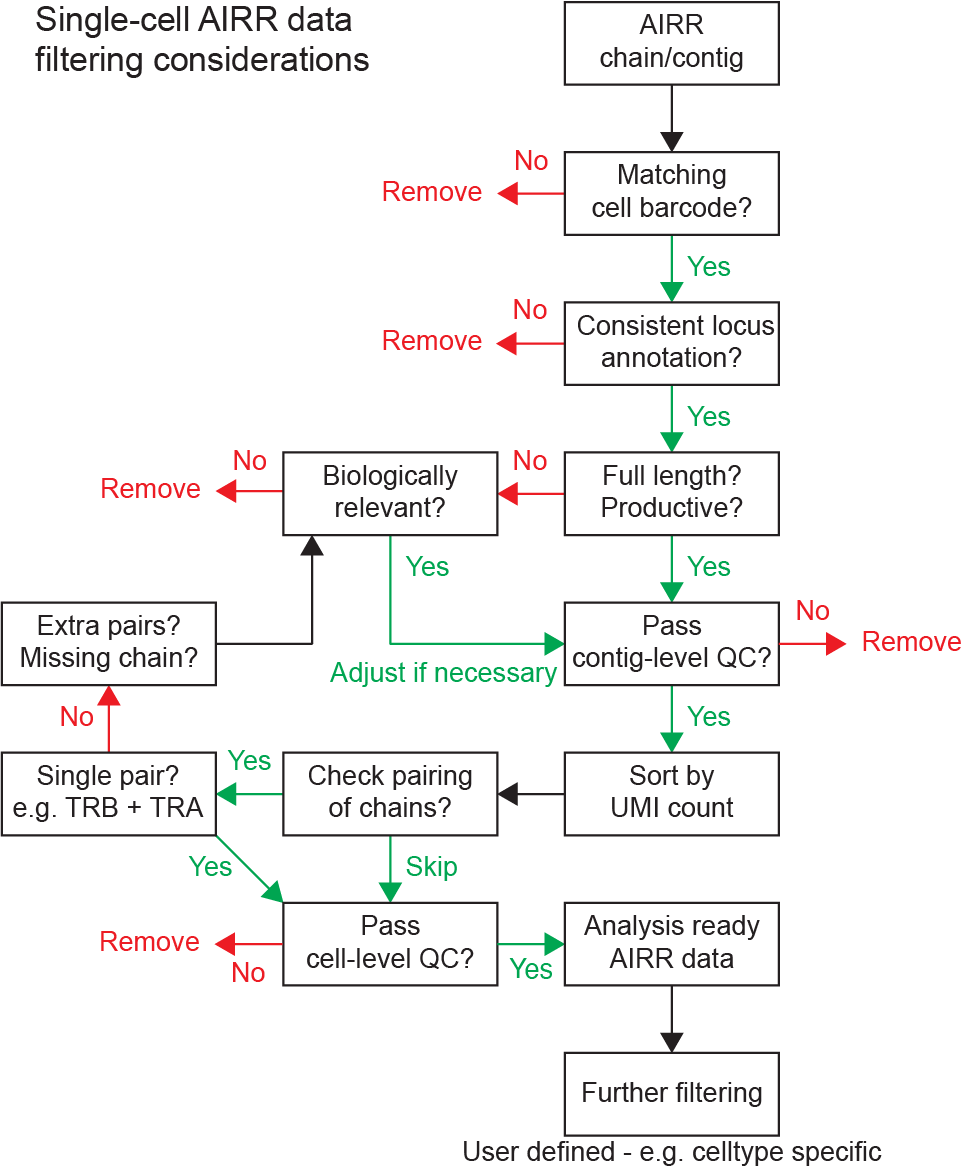

In [13]:
print("Before QC VDJ :", vdj)
print("Before QC GEX :", adata.shape)
vdj, adata = ddl.pp.check_contigs(vdj, adata)
print("After QC VDJ :", vdj)
print("After QC GEX :", adata.shape)

Before QC VDJ : Lazy Dandelion object with n_obs = 7689 and n_contigs = 19286
    data: sequence_id, sequence, rev_comp, productive, v_call, d_call, j_call, sequence_alignment, germline_alignment, junction, junction_aa, v_cigar, d_cigar, j_cigar, stop_codon, vj_in_frame, locus, c_call, junction_length, np1_length, np2_length, v_sequence_start, v_sequence_end, v_germline_start, v_germline_end, d_sequence_start, d_sequence_end, d_germline_start, d_germline_end, j_sequence_start, j_sequence_end, j_germline_start, j_germline_end, v_score, v_identity, v_support, d_score, d_identity, d_support, j_score, j_identity, j_support, fwr1, fwr2, fwr3, fwr4, cdr1, cdr2, cdr3, cell_id, consensus_count, umi_count, v_call_10x, d_call_10x, j_call_10x, junction_10x, junction_10x_aa, j_support_igblastn, j_score_igblastn, j_call_igblastn, j_call_blastn, j_identity_blastn, j_alignment_length_blastn, j_number_of_mismatches_blastn, j_number_of_gap_openings_blastn, j_sequence_start_blastn, j_sequence_end_blastn

In [14]:
# What chain compositions do we see?
adata.obs["chain_status"].value_counts(dropna=False)

,count
chain_status,
Single pair,5814
NaN,5749
Ambiguous,1059
Orphan VDJ,639
Extra pair,97
Orphan VJ,80


---
### 🏋️ Exercise 2 — Inspect chain status distribution

After `ddl.pp.check_contigs`, the `chain_status` column in `adata.obs` summarises the TCR completeness of each cell.

1. Print the value counts for `chain_status` — what categories exist?
2. What fraction of cells have a clean `Single pair`?
3. *(Bonus)* Visualize `chain_status` on the existing UMAP (if it's available in `adata.obsm`).

**Hint:** `adata.obs["chain_status"].value_counts()` — or use pandas `.value_counts(normalize=True)` for proportions.
For the bonus: `sc.pl.umap(adata, color="chain_status")` — but first check `adata.obsm.keys()` to confirm the UMAP is there.

In [15]:
# 1 & 2. Value counts + proportions
print(adata.obs["chain_status"].value_counts())
print()
print(adata.obs["chain_status"].value_counts(normalize=True).round(3))

# Bonus: UMAP coloured by chain_status
# print(adata.obsm.keys())
# sc.pl.umap(adata, color="chain_status")

chain_status
Single pair    5814
Ambiguous      1059
Orphan VDJ      639
Extra pair       97
Orphan VJ        80
Name: count, dtype: int64

chain_status
Single pair    0.756
Ambiguous      0.138
Orphan VDJ     0.083
Extra pair     0.013
Orphan VJ      0.010
Name: proportion, dtype: float64


For the rest of the tutorial we focus on cells with a clean `Single pair`.
These are the healthy αβ T cells where we can confidently link a clonotype to a transcriptomic state.
`NaN` cells without any TCR are also kept in `adata` for the UMAP, but they will appear as "missing" in clone-related plots.

## Define clonotypes

A clonotype groups cells that descended from the same T cell ancestor.

For TCR data, the standard definition is: identical V gene + identical J gene + identical CDR3 amino-acid sequence on the matched chains. (TCRs don't undergo somatic hypermutation, unlike BCRs, so identity is the natural cutoff.)

Dandelion's `find_clones` implements this directly.

In [16]:
ddl.tl.find_clones(vdj)

meta = vdj.metadata.collect()
clones = (
    meta.group_by("clone_id")
    .agg(pl.len().alias("n_cells"))
    .sort("n_cells", descending=True)
)
clones

Using NumPy backend (CPU only)


Finding clones based on abT cell VDJ chains using junction: 100%|██████████| 2469/2469 [00:00<00:00, 3795.99it/s]
Finding clones based on abT cell VJ chains using junction: 100%|██████████| 4092/4092 [00:00<00:00, 5438.31it/s]
Finding clones based on gdT cell VDJ chains using junction: 100%|██████████| 1/1 [00:00<00:00, 3086.32it/s]
Building distance matrix (batched): 100%|██████████| 66/66 [00:00<00:00, 1920.80it/s]


clone_id,n_cells
str,u32
"""abT_VDJ_352_3_2_VJ_537_1_1""",76
"""abT_VDJ_345_2_1_VJ_37_1_1""",50
"""abT_VDJ_314_1_5_VJ_340_3_1""",38
"""abT_VDJ_455_3_1_VJ_109_3_1""",29
"""abT_VDJ_341_5_2_VJ_1002_1_1""",26
…,…
"""abT_VDJ_454_3_2_VJ_1437_1_1""",1
"""abT_VDJ_98_5_1_VJ_468_2_1""",1
"""abT_VDJ_286_4_1_VJ_1107_1_1""",1


---
### 🏋️ Exercise 3 — Investigate the largest clonotypes

After running `ddl.tl.find_clones`, each cell gets a `clone_id`.

1. How many unique clonotypes were identified?
2. What are the top 5 largest clonotypes (by number of cells)?
3. For the largest clonotype, look up its `junction_aa` (CDR3 amino-acid sequence) in `vdj.data`.

**Hint:**
- `vdj.metadata.collect()` has the per-cell clone assignments
- Group by `clone_id` and count: `meta.group_by("clone_id").agg(pl.len().alias("n_cells")).sort("n_cells", descending=True)`
- Then filter `vdj.data.collect()` by that `clone_id` and select the `junction_aa` column

In [17]:
meta = vdj.metadata.collect()

# 1. Number of unique clonotypes (exclude null/unassigned)
n_clones = meta.filter(pl.col("clone_id").is_not_null())["clone_id"].n_unique()
print("Unique clonotypes:", n_clones)

# 2. Top 5 largest
top5 = (
    meta.group_by("clone_id")
    .agg(pl.len().alias("n_cells"))
    .sort("n_cells", descending=True)
    .head(5)
)
print(top5)

# 3. CDR3 sequences for the largest clone
largest_id = top5["clone_id"][0]
# TODO: filter vdj.data to this clone_id and select junction_aa

Unique clonotypes: 6735
shape: (5, 2)
┌─────────────────────────────┬─────────┐
│ clone_id                    ┆ n_cells │
│ ---                         ┆ ---     │
│ str                         ┆ u32     │
╞═════════════════════════════╪═════════╡
│ abT_VDJ_352_3_2_VJ_537_1_1  ┆ 76      │
│ abT_VDJ_345_2_1_VJ_37_1_1   ┆ 50      │
│ abT_VDJ_314_1_5_VJ_340_3_1  ┆ 38      │
│ abT_VDJ_455_3_1_VJ_109_3_1  ┆ 29      │
│ abT_VDJ_341_5_2_VJ_1002_1_1 ┆ 26      │
└─────────────────────────────┴─────────┘


## Quantify clonal expansion

Once we have clonotypes, we want to know how big each one is. Dandelion's `clone_size` adds three new columns to `vdj.metadata`:

- `clone_id_size`: the raw cell count for each clone
- `clone_id_size_prop`: the same as a proportion of all cells
- `clone_id_size_category`: a standard binning into Rare, Small, Medium, Large, Hyperexpanded, matching the scRepertoire convention.

Passing `max_size=3` adds another column that caps the size at 3 (`clone_id_size_max_3`). Together with the categorical column, these options make downstream plots much more readable.

In [18]:
ddl.tl.clone_size(
    vdj
)  # adds 'clone_id_size', "clone_id_size_prop", "clone_id_size_category"
ddl.tl.clone_size(vdj, max_size=3)  # adds 'clone_id_size_max_3'

meta = vdj.metadata.collect()
meta.select(
    [
        "clone_id",
        "clone_id_size",
        "clone_id_size_max_3",
        "clone_id_size_prop",
        "clone_id_size_category",
    ]
).head()

clone_id,clone_id_size,clone_id_size_max_3,clone_id_size_prop,clone_id_size_category
str,f64,str,f64,str
"""abT_VDJ_188_3_1_VJ_134_1_2""",1.0,"""1""",0.00013,"""Small"""
"""abT_VDJ_490_6_4_VJ_1589_1_1""",1.0,"""1""",0.00013,"""Small"""
"""abT_VDJ_472_1_1""",1.0,"""1""",0.00013,"""Small"""
"""abT_VDJ_303_8_1_VJ_802_3_1""",1.0,"""1""",0.00013,"""Small"""
"""abT_VDJ_164_3_4_VJ_1103_5_1""",1.0,"""1""",0.00013,"""Small"""


## Build the clonotype network

A clonotype network is a graph where each node is a cell and edges connect cells in the same clonotype. Expanded clonotypes form large connected clusters, whereas singleton clonotypes appear as isolated nodes. `generate_network` constructs this graph and computes a layout for visualisation.

In [19]:
ddl.tl.generate_network(vdj, key="junction_aa", layout_method="mod_fr2")

## Integrate Dandelion into the AnnData

The generated network is stored within the Dandelion object. Since `ddl.pl.clone_network` operates on an AnnData object, we first use `ddl.tl.transfer` to transfer the repertoire annotations, graph structure, and layout coordinates from Dandelion to the matching AnnData. This will push `vdj.metadata` columns into `adata.obs`, and the network's layout + graph into `adata.obsm` / `adata.obsp`.

In [20]:
ddl.tl.transfer(adata, vdj)
adata.obs[
    [
        "clone_id",
        "clone_id_size",
        "clone_id_size_max_3",
        "clone_id_size_category",
        "chain_status",
    ]
].head()

,clone_id,clone_id_size,clone_id_size_max_3,clone_id_size_category,chain_status
PICA0175-0213_Pool_6_AAACCAAAGAAAGTGC,abT_VDJ_188_3_1_VJ_134_1_2,1.0,1,Small,Single pair
PICA0175-0213_Pool_6_AAACCAAAGAGAGTTA,NaN,NaN,NaN,NaN,NaN
PICA0175-0213_Pool_6_AAACCAAAGGTCACGT,abT_VDJ_490_6_4_VJ_1589_1_1,1.0,1,Small,Single pair
PICA0175-0213_Pool_6_AAACCAGCAACGTTTA,NaN,NaN,NaN,NaN,NaN
PICA0175-0213_Pool_6_AAACCAGCAACTTAGC,NaN,NaN,NaN,NaN,NaN


## Visualize clonal expansion

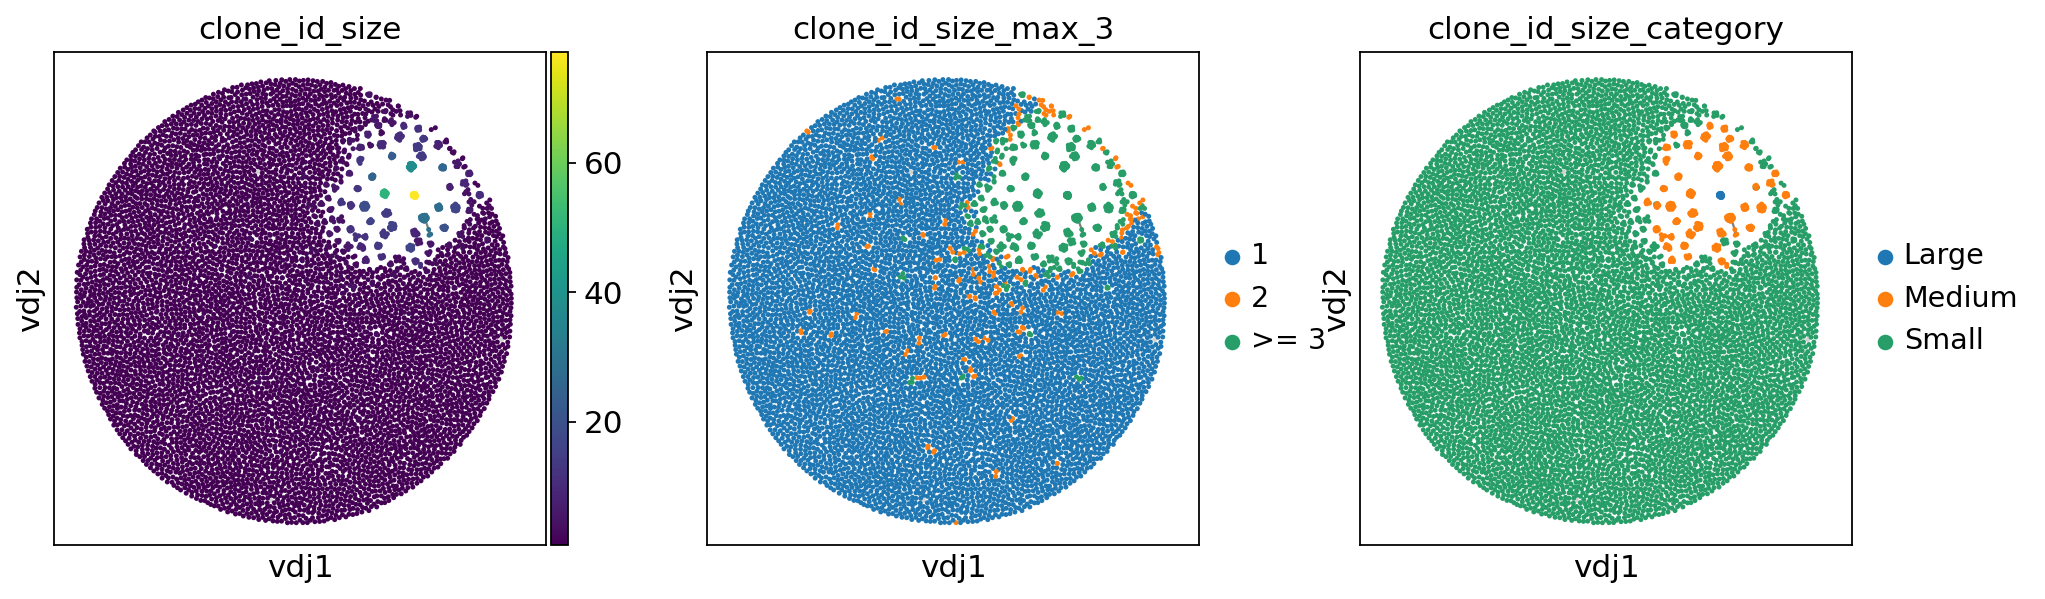

In [21]:
sc.set_figure_params(figsize=[4, 4])
ddl.pl.clone_network(
    adata,
    color=["clone_id_size", "clone_id_size_max_3", "clone_id_size_category"],
    edges_width=1,
    size=20,
    na_in_legend=False,
)

### Zooming in on expanded clones only

`ddl.tl.clone_view(adata, mode="expanded")` switches the active embedding to one that contains only cells in clones with >1 cell, making expansion patterns much easier to see. Switch back with `mode="all"` (or `mode="rna"` to use the original GEX UMAP).

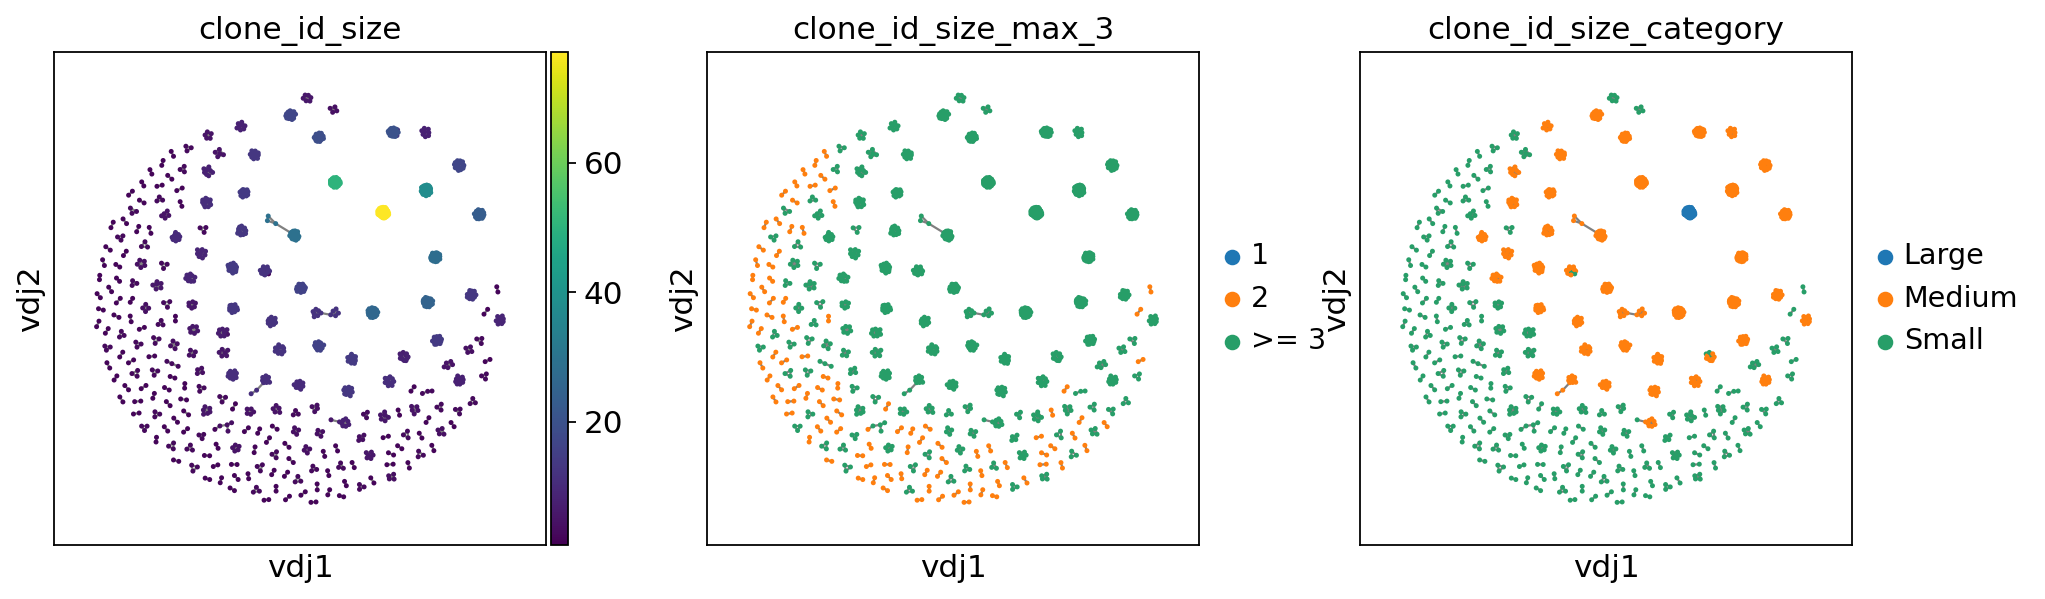

In [22]:
ddl.tl.clone_view(adata, mode="expanded")

ddl.pl.clone_network(
    adata,
    color=["clone_id_size", "clone_id_size_max_3", "clone_id_size_category"],
    edges_width=1,
    size=20,
    na_in_legend=False,
)

### Bring in gene expression

Now we layer GEX onto this.

/tmp/ipykernel_1211/2832217464.py:7: ImplicitModificationWarning: Setting element `.layers['counts']` of view, initializing view as actual.
/usr/lib/python3.12/functools.py:912: UserWarning: Received a view of an AnnData. Making a copy.
/usr/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
/tmp/ipykernel_1211/2832217464.py:17: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.


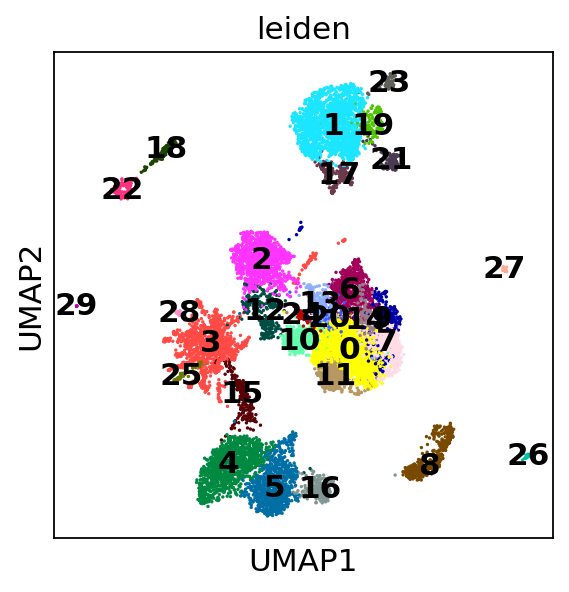

In [23]:
adata.var["mt"] = adata.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], inplace=True)
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)
adata = adata[adata.obs["n_genes_by_counts"] < 5000, :]
adata = adata[adata.obs["pct_counts_mt"] < 10, :]
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=1000)
adata.raw = adata
adata = adata[:, adata.var["highly_variable"]]
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.tl.leiden(adata, resolution=1.0)
sc.pl.umap(adata, color="leiden", legend_loc="on data")

Cells sharing the same TCR have likely responded to the same antigen. Colour the UMAP by expansion category so that singletons, small clones, and large clones are easy to distinguish. Non-T cells (no TCR) appear as grey background.

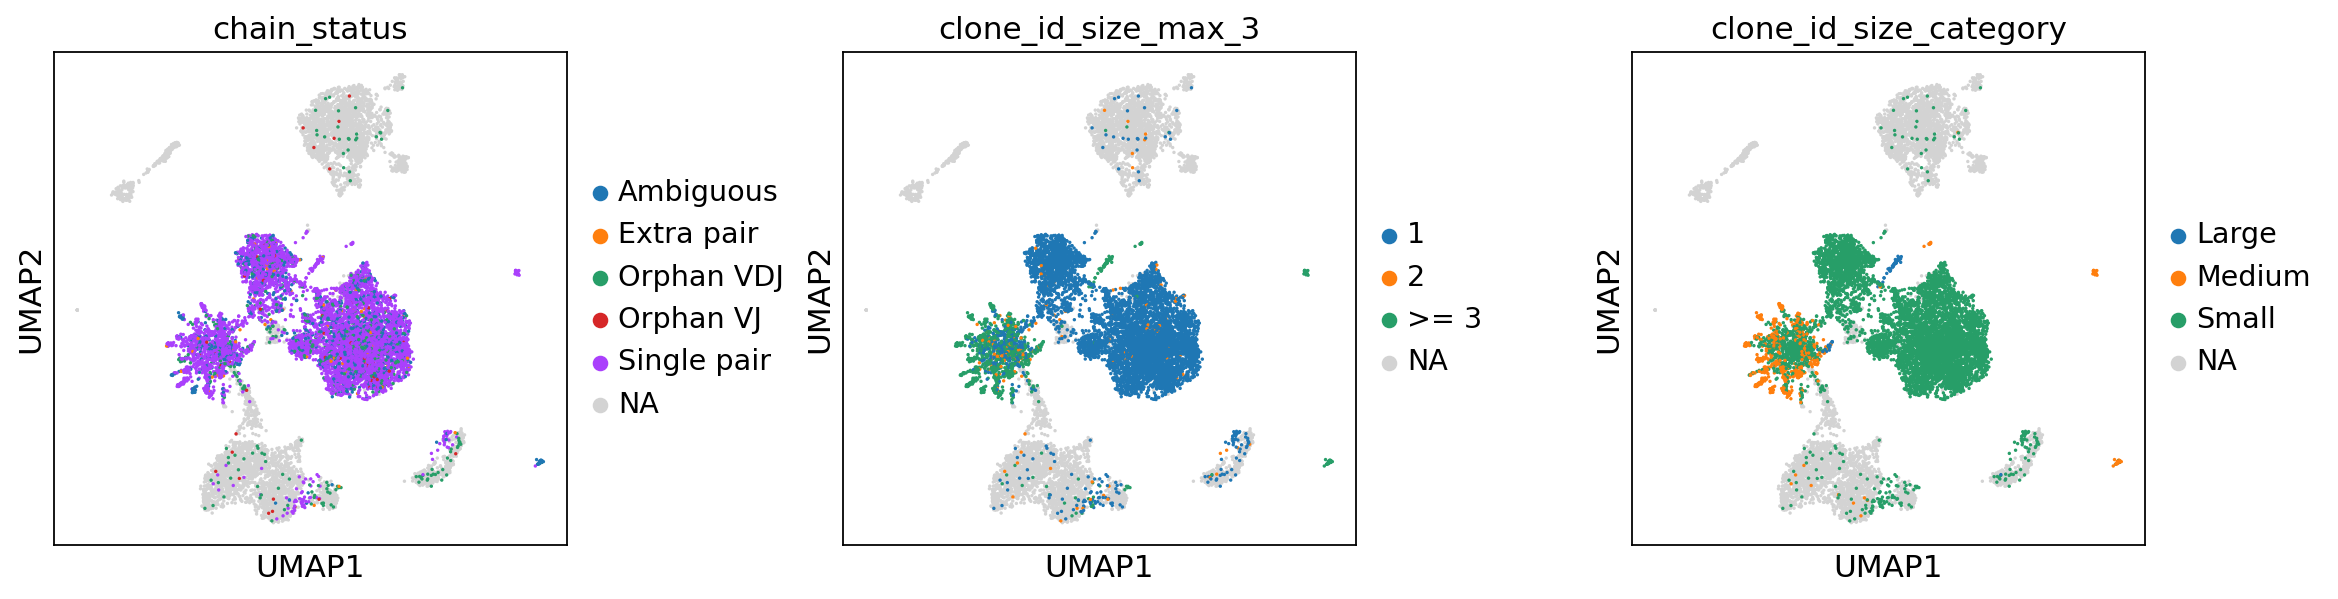

In [24]:
sc.pl.umap(
    adata,
    color=["chain_status", "clone_id_size_max_3", "clone_id_size_category"],
    wspace=0.4,
)

Expanded clones (Medium / Large / Hyperexpanded) typically concentrate in specific regions of the UMAP, usually corresponding to effector or memory T cell states.

## Compare PICA0208 vs PICA0209

Now let's bring in the second sample and ask a simple question: do the two samples expand the same clonotypes, and to what extent?

We load PICA0209, run the same QC + clone-calling on it, then put them together in a single `ddl.pl.clone_circlepackplot` -- a bubble plot where each clone is one circle, sized by its cell count.

In [25]:
# Load PICA0209 and run the same minimal pipeline
adata_209 = sc.read_h5ad("adata_PICA0209.h5ad")
vdj_209 = ddl.read_zipddl("vdj_PICA0209.zipddl")

vdj_209, adata_209 = ddl.pp.check_contigs(vdj_209, adata_209)
ddl.tl.find_clones(vdj_209)
ddl.tl.clone_size(vdj_209)

# Tag each vdj with a sample_id and concatenate
vdj.data = vdj.data.with_columns(pl.lit("PICA0208").alias("sample_id"))
vdj_209.data = vdj_209.data.with_columns(pl.lit("PICA0209").alias("sample_id"))
vdj.metadata = vdj.metadata.with_columns(pl.lit("PICA0208").alias("sample_id"))
vdj_209.metadata = vdj_209.metadata.with_columns(pl.lit("PICA0209").alias("sample_id"))

vdj_both = ddl.tl.concat([vdj, vdj_209])
print(vdj_both)

Filtering contigs...
Marking ambiguous contigs...
Initializing DandelionPolars object...
Using NumPy backend (CPU only)


Finding clones based on abT cell VDJ chains using junction: 100%|██████████| 2583/2583 [00:00<00:00, 3870.36it/s]
Finding clones based on abT cell VJ chains using junction: 100%|██████████| 4512/4512 [00:00<00:00, 4941.77it/s]
Finding clones based on gdT cell VDJ chains using junction: 100%|██████████| 4/4 [00:00<00:00, 7660.83it/s]
Building distance matrix (batched): 100%|██████████| 71/71 [00:00<00:00, 1373.68it/s]


Lazy Dandelion object with n_obs = 15627 and n_contigs = 32003
    data: sequence_id, sequence, rev_comp, productive, v_call, d_call, j_call, sequence_alignment, germline_alignment, junction, junction_aa, v_cigar, d_cigar, j_cigar, stop_codon, vj_in_frame, locus, c_call, junction_length, np1_length, np2_length, v_sequence_start, v_sequence_end, v_germline_start, v_germline_end, d_sequence_start, d_sequence_end, d_germline_start, d_germline_end, j_sequence_start, j_sequence_end, j_germline_start, j_germline_end, v_score, v_identity, v_support, d_score, d_identity, d_support, j_score, j_identity, j_support, fwr1, fwr2, fwr3, fwr4, cdr1, cdr2, cdr3, cell_id, consensus_count, umi_count, v_call_10x, d_call_10x, j_call_10x, junction_10x, junction_10x_aa, j_support_igblastn, j_score_igblastn, j_call_igblastn, j_call_blastn, j_identity_blastn, j_alignment_length_blastn, j_number_of_mismatches_blastn, j_number_of_gap_openings_blastn, j_sequence_start_blastn, j_sequence_end_blastn, j_germline_st

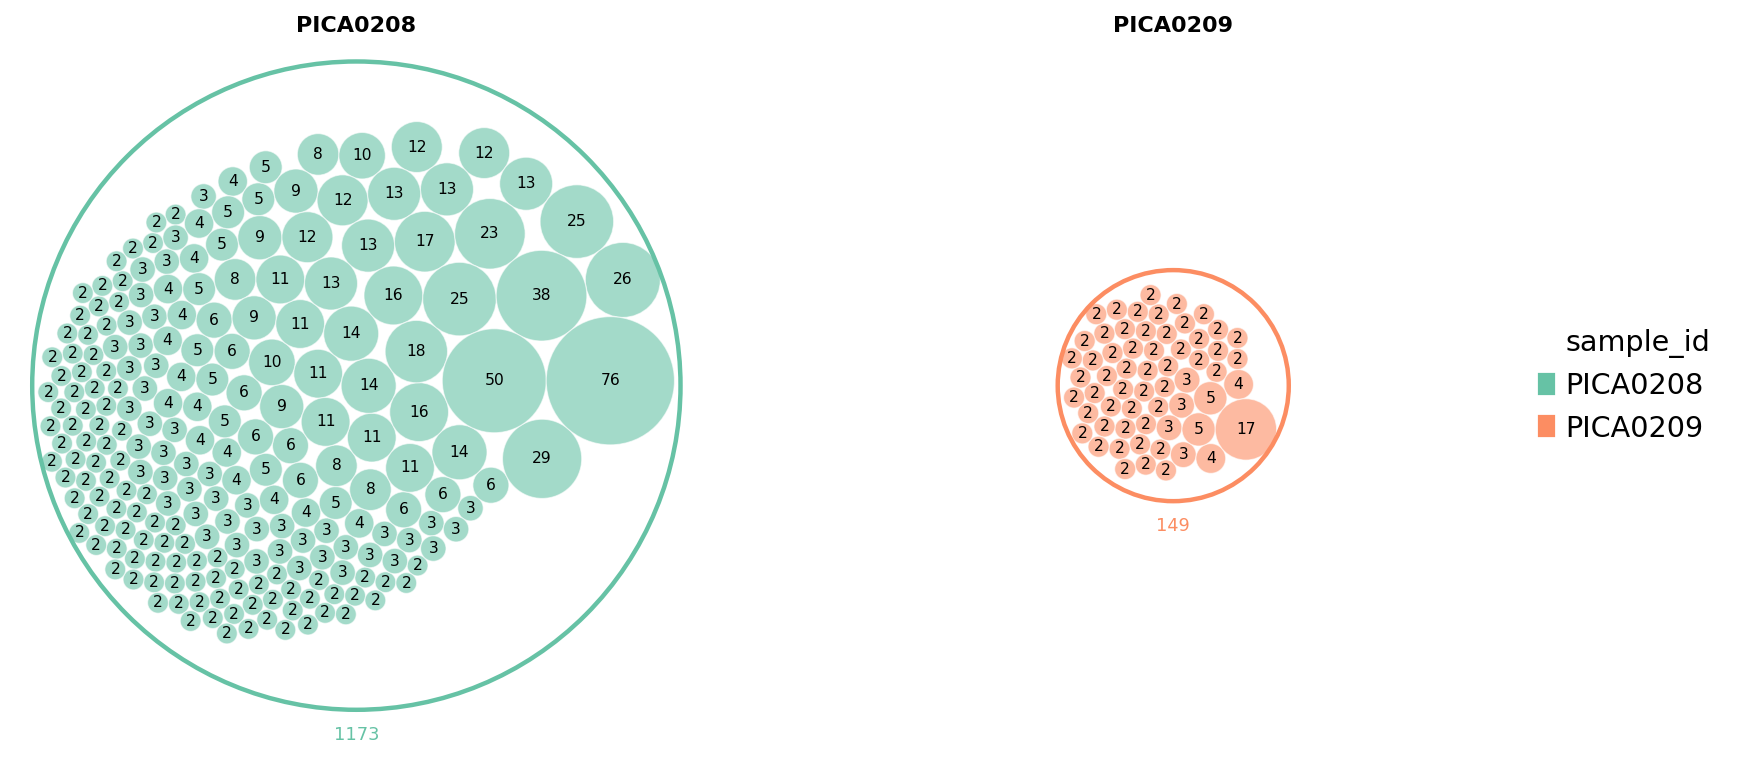

In [26]:
# Circle pack plot: each circle is one clone, sized by cell count;
# outer circle groups clones by sample, panels share the same scale
# so circle areas are directly comparable across samples.
ddl.pl.clone_circlepackplot(
    vdj_both,
    group_by="sample_id",
    min_clone_size=2,  # hide singletons for clarity
    as_subplots=True,  # one panel per sample
    show_count_labels=True,
    figsize=(6, 6),
)
plt.show()

---
### 🏋️ Exercise 4 — Compare expansion across the two samples

The `clone_circlepackplot` we ran showed each sample separately. Now let's dig a little deeper.

1. After running the two-sample pipeline above, colour the **combined UMAP** by `clone_id_size_category`.
   Do expanded clones concentrate in particular regions?
2. Try plotting the UMAP for each sample side-by-side: filter `adata_combined` to one sample,
   then the other, and call `sc.pl.umap` on each.

**Hint:**
- First you'll need to transfer clone info from `vdj_both` into a combined AnnData — check the `ddl.tl.transfer` docs.
- `sc.pl.umap(adata_combined, color=["clone_id_size_category", "sample_id"])` is a good starting point.
- **Docs:** `?ddl.tl.transfer`, `?sc.pl.umap`

In [ ]:
# Transfer clone info from the combined Dandelion object into the combined AnnData

# TODO: ddl.tl.transfer(adata_combined, vdj_both)

# Then colour the UMAP
# sc.pl.umap(
#     adata_combined,
#     color=["clone_id_size_category", "sample_id"],
#     wspace=0.4,
# )

## Summary

In this tutorial we added TCR information to single-cell data:

1. Met the biology and the file formats coming out of a 10x/SeekGene V(D)J run
2. Loaded GEX (`.h5ad`) and VDJ (`.zipddl`)
3. Explored the one row per contig AIRR table
4. QC'd contigs with `ddl.pp.check_contigs`
5. Defined clonotypes with `ddl.tl.find_clones`
6. Quantified expansion with `ddl.tl.clone_size`
7. Built a clonotype network with `ddl.tl.generate_network`
8. Transferred TCR info into the GEX AnnData with `ddl.tl.transfer`
9. Visualised the network via `ddl.tl.clone_view` and `ddl.pl.clone_network`
10. Layered TCR features on the GEX UMAP
11. Compared two samples with `ddl.pl.clone_circlepackplot`

Key takeaways
- `vdj.data`: long, one row per contig (the AIRR table), polars LazyFrame
- `vdj.metadata`: wide, one row per cell, chains summarised, polars LazyFrame
- `adata.obs`: gains `clone_id`, `clone_id_size`, `chain_status`, … (pandas)